In [1]:
!pip install ultralytics -q

from ultralytics import YOLO
import matplotlib.pyplot as plt
from PIL import Image
print("✅ Setup Complete!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Setup Complete!


# Day 14: Pose Estimation with YOLO11-pose

## Key Concepts Learned Today

**Note 1: What is Pose Estimation?**
- Not just detecting a person, but finding **key points** (joints) like:
  - Nose, Eyes, Ears
  - Shoulders, Elbows, Wrists
  - Hips, Knees, Ankles

**Note 2: Why is this advanced?**
- Goes beyond bounding boxes and segmentation
- Useful for: Action recognition, Fitness apps, Security, Healthcare, Animation

**Note 3: YOLO11-pose vs Normal Detection**
- Normal YOLO → Only draws a box around person
- YOLO-pose → Draws skeleton (17 keypoints per person)


image 1/1 /content/bus.jpg: 640x480 4 persons, 561.7ms
Speed: 12.7ms preprocess, 561.7ms inference, 36.4ms postprocess per image at shape (1, 3, 640, 480)


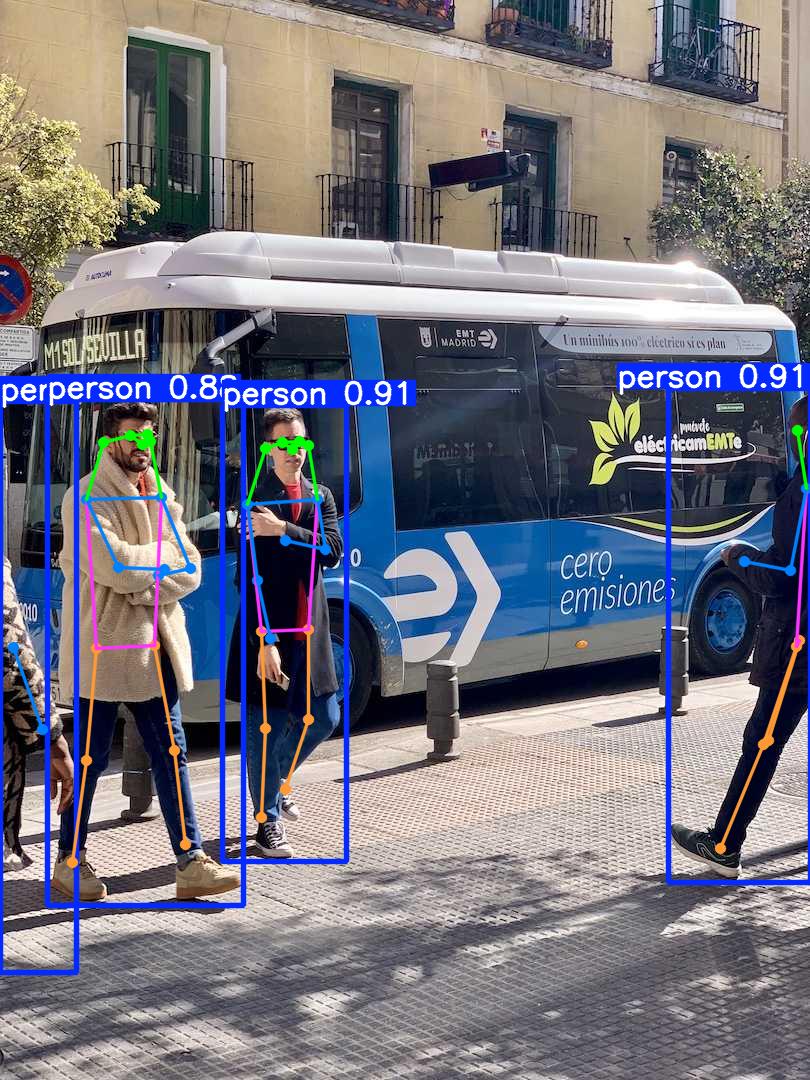

'pose_result.jpg'

In [2]:
# Load Pose Estimation Model
model = YOLO("yolo11s-pose.pt")

# Run on image
results = model("https://ultralytics.com/images/bus.jpg", conf=0.3)

# Show result with keypoints
results[0].show()

# Save output
results[0].save("pose_result.jpg")

## Keypoint Analysis Explanation

**Note:**
- Each person has 17 keypoints
- We can calculate angles, distances, and actions

In [4]:
import numpy as np
result = results[0]

if result.keypoints is not None:
    for i, person in enumerate(result.keypoints.data):
        print(f"\nPerson {i+1}:")
        keypoints = person.cpu().numpy()

        # Example: Calculate shoulder width
        left_shoulder = keypoints[5]
        right_shoulder = keypoints[6]
        shoulder_width = np.linalg.norm(left_shoulder - right_shoulder)

        print(f"Shoulder Width: {shoulder_width:.1f} pixels")


Person 1:
Shoulder Width: 69.5 pixels

Person 2:
Shoulder Width: 6.3 pixels

Person 3:
Shoulder Width: 74.7 pixels

Person 4:
Shoulder Width: 0.2 pixels


In [5]:
import gradio as gr

def pose_analysis(image):
    results = model(image, conf=0.3)
    annotated = results[0].plot()
    return annotated

with gr.Blocks(title="Pose Estimation Analyzer") as demo:
    gr.Markdown("# 🏃‍♂️ YOLO11 Pose Estimation")
    gr.Markdown("### Detect human keypoints and skeleton")

    input_img = gr.Image(type="pil", label="Upload Image")
    output_img = gr.Image(label="Pose Estimation Result")

    btn = gr.Button("Analyze Pose")
    btn.click(pose_analysis, inputs=input_img, outputs=output_img)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f42efe148515ec27c4.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
